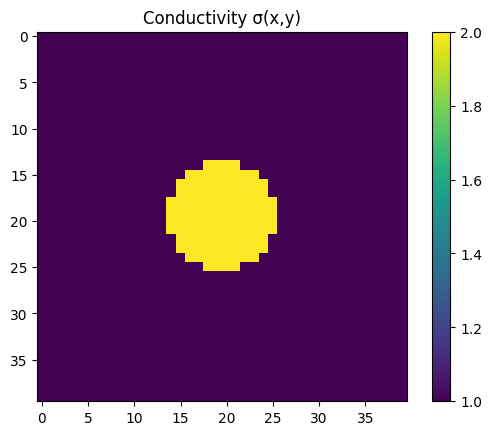

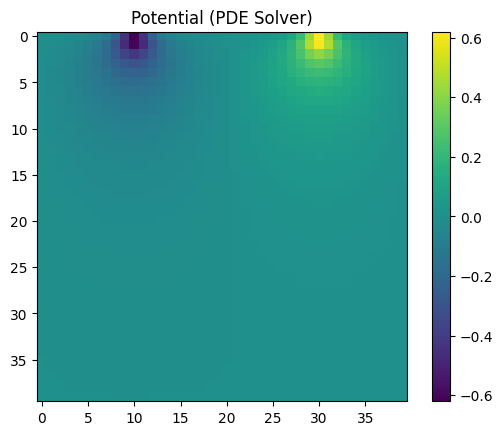

In [1]:
!pip install torch numpy scipy matplotlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Nx = 40
Ny = 40

x = np.linspace(0,1,Nx)
y = np.linspace(0,1,Ny)

X,Y = np.meshgrid(x,y)

dx = 1/Nx
dy = 1/Ny

sigma = np.ones((Nx,Ny))

cx,cy = 0.5,0.5
r = 0.15

mask = (X-cx)**2 + (Y-cy)**2 < r**2
sigma[mask] = 2

plt.imshow(sigma)
plt.title("Conductivity σ(x,y)")
plt.colorbar()
plt.show()

source = (10,0)
sink   = (30,0)

I = 1

def gaussian_source(X,Y,x0,y0,eps=0.02):

    return np.exp(
        -((X-x0)**2 + (Y-y0)**2)/(2*eps**2)
    )

def idx(i,j):
    return i*Ny + j

def solve_pde(sigma):

    N = Nx*Ny

    A = lil_matrix((N,N))
    b = np.zeros(N)

    for i in range(Nx):
        for j in range(Ny):

            k = idx(i,j)

            A[k,k] = -4

            if i>0:
                A[k,idx(i-1,j)] = 1
            if i<Nx-1:
                A[k,idx(i+1,j)] = 1
            if j>0:
                A[k,idx(i,j-1)] = 1
            if j<Ny-1:
                A[k,idx(i,j+1)] = 1

    # source term
    f = gaussian_source(X,Y,x[source[0]],y[source[1]]) \
        - gaussian_source(X,Y,x[sink[0]],y[sink[1]])

    b = f.flatten()

    phi = spsolve(A.tocsr(),b)

    return phi.reshape((Nx,Ny))

phi_pde = solve_pde(sigma)

plt.imshow(phi_pde)
plt.title("Potential (PDE Solver)")
plt.colorbar()
plt.show()


In [2]:
XY = np.vstack([X.flatten(),Y.flatten()]).T

xy = torch.tensor(XY,dtype=torch.float32).to(device)
phi_true = torch.tensor(phi_pde.flatten(),dtype=torch.float32).unsqueeze(1).to(device)

sigma_torch = torch.tensor(sigma.flatten(),dtype=torch.float32).unsqueeze(1).to(device)

In [3]:
class PINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,128),
            nn.Tanh(),
            nn.Linear(128,128),
            nn.Tanh(),
            nn.Linear(128,128),
            nn.Tanh(),
            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.net(x)

In [4]:
model = PINN().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)

In [5]:
def pde_residual(model,xy):

    xy.requires_grad_(True)

    phi = model(xy)

    grad = torch.autograd.grad(
        phi,xy,
        grad_outputs=torch.ones_like(phi),
        create_graph=True
    )[0]

    phi_x = grad[:,0:1]
    phi_y = grad[:,1:2]

    grad_x = torch.autograd.grad(
        phi_x,xy,
        grad_outputs=torch.ones_like(phi_x),
        create_graph=True
    )[0]

    grad_y = torch.autograd.grad(
        phi_y,xy,
        grad_outputs=torch.ones_like(phi_y),
        create_graph=True
    )[0]

    phi_xx = grad_x[:,0:1]
    phi_yy = grad_y[:,1:2]

    return phi_xx + phi_yy

In [6]:
def gaussian_source(x, y, x0, y0, eps=0.02):

    return torch.exp(
        -((x-x0)**2 + (y-y0)**2)/(2*eps**2)
    )

In [7]:
x_t = x[source[0]]
y_t = y[source[1]]

x_s = x[sink[0]]
y_s = y[sink[1]]

x_tensor = xy[:,0:1]
y_tensor = xy[:,1:2]

f = gaussian_source(x_tensor,y_tensor,x_t,y_t) \
    - gaussian_source(x_tensor,y_tensor,x_s,y_s)

f = f.to(device)

In [8]:
epochs = 50000

for e in range(epochs):

    optimizer.zero_grad()

    # predicción
    phi_pred = model(xy)

    # calcular laplaciano
    laplacian_phi = pde_residual(model,xy)

    # recalcular la fuente cada iteración
    x_tensor = xy[:,0:1]
    y_tensor = xy[:,1:2]

    f = gaussian_source(x_tensor,y_tensor,x_t,y_t) \
        - gaussian_source(x_tensor,y_tensor,x_s,y_s)

    f = f.to(device)

    # residual PDE
    res = laplacian_phi - f

    loss_pde = torch.mean(res**2)

    loss_data = torch.mean((phi_pred - phi_true)**2)

    loss = loss_pde + 1000*loss_data

    loss.backward()

    optimizer.step()

    if e%10000==0:
        print(e,loss.item())

0 20.798397064208984
10000 0.4404793083667755
20000 0.24332064390182495
30000 0.28041285276412964
40000 0.22115981578826904


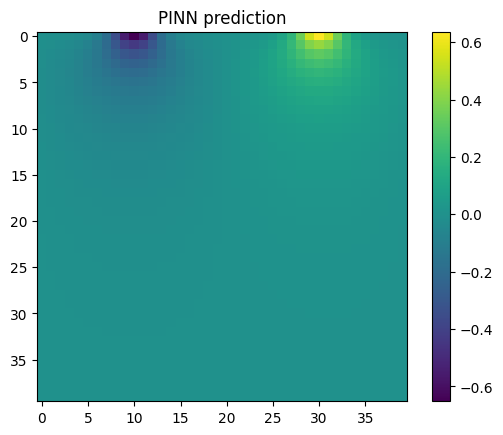

In [9]:
phi_pinn = model(xy).detach().cpu().numpy().reshape((Nx,Ny))

plt.imshow(phi_pinn)
plt.title("PINN prediction")
plt.colorbar()
plt.show()

Relative error: 0.18476729010181694


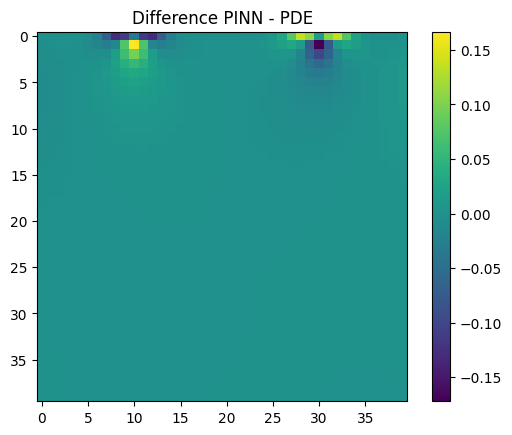

In [10]:
error = np.linalg.norm(phi_pinn - phi_pde)/np.linalg.norm(phi_pde)

print("Relative error:",error)

plt.imshow(phi_pinn - phi_pde)
plt.title("Difference PINN - PDE")
plt.colorbar()
plt.show()